# Decision Tree Tutorial

This notebook provides a detailed walkthrough of Decision Trees for both classification and regression tasks. We will cover the necessary steps from model training and testing to evaluation and interpretation.

## Part 1: Decision Tree for Classification

### 1.1 Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 1.2 Loading the Data

In [2]:
iris = load_iris()
X_cls = iris.data
y_cls = iris.target

### 1.3 Splitting the Data

In [3]:
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(X_cls, y_cls, test_size=0.3, random_state=42)

### 1.4 Training the Decision Tree Classifier

In [4]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_cls_train, y_cls_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 1.5 Making Predictions

In [5]:
y_cls_pred = clf.predict(X_cls_test)

### 1.6 Evaluating the Model

In [6]:
print(f'Accuracy: {accuracy_score(y_cls_test, y_cls_pred):.2f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_cls_test, y_cls_pred))
print('\nClassification Report:')
print(classification_report(y_cls_test, y_cls_pred, target_names=iris.target_names))

Accuracy: 1.00

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### 1.7 Visualizing the Decision Tree

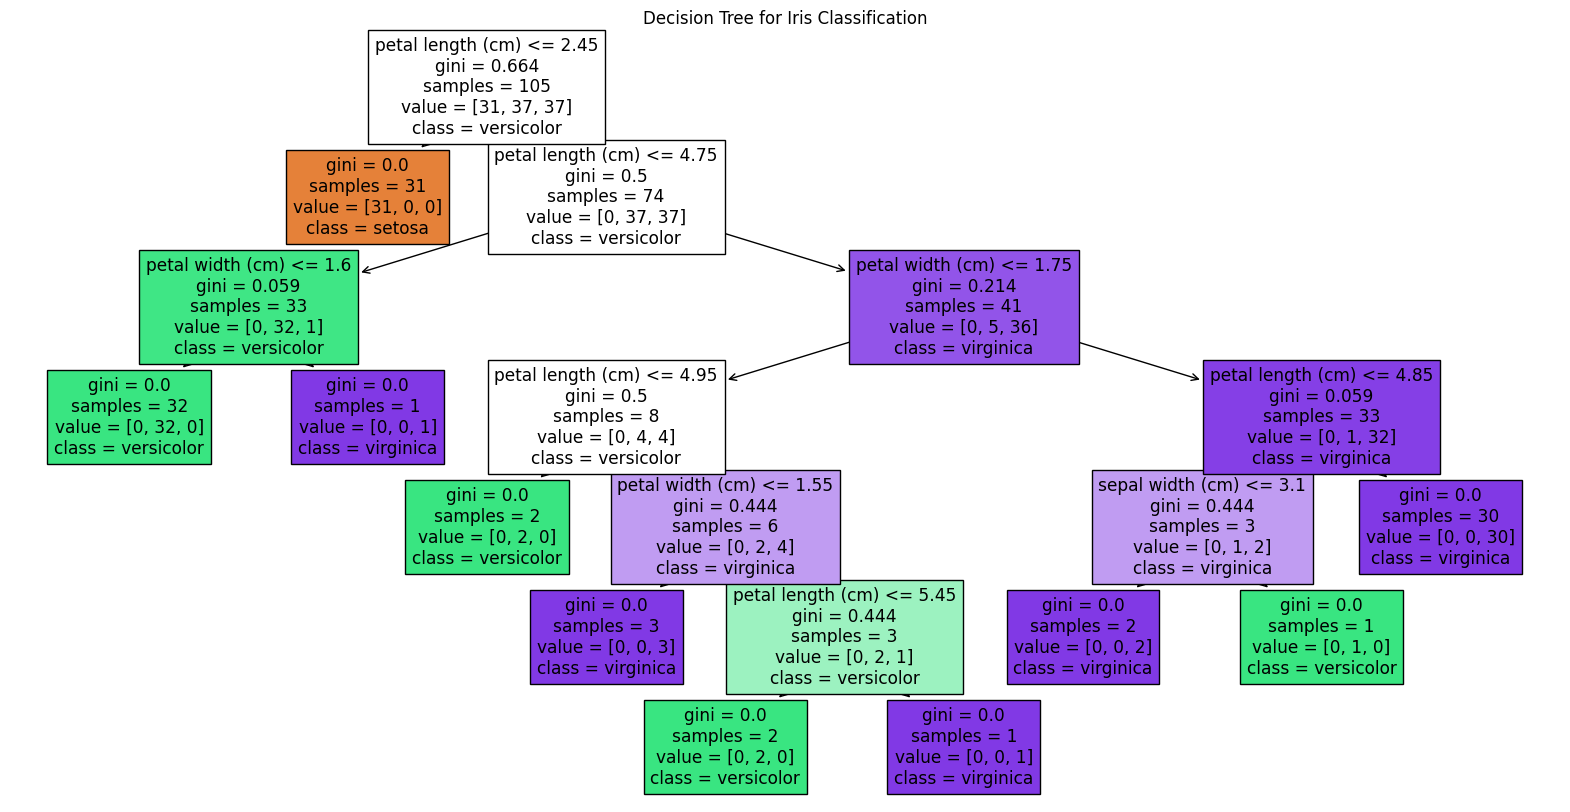

In [7]:
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=iris.feature_names, class_names=list(iris.target_names), filled=True)
plt.title('Decision Tree for Iris Classification')
plt.show()

### 1.8 Interpretation

The decision tree visualization helps us understand how the model makes predictions. 
- Each node represents a decision based on a feature.
- The `gini` value measures the impurity of the node; a value of 0 means all samples in the node belong to the same class.
- The `samples` value shows how many training samples are in the node.
- The `value` array shows the distribution of samples among the classes.
- The `class` indicates the predicted class for the samples in that node.

## Part 2: Decision Tree for Regression

### 2.1 Importing Libraries

In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

### 2.2 Creating Synthetic Data

In [9]:
np.random.seed(42)
X_reg = np.random.rand(100, 1) * 10
y_reg = np.sin(X_reg).ravel() + np.random.randn(100) * 0.5

### 2.3 Splitting the Data

In [10]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

### 2.4 Training the Decision Tree Regressor

In [11]:
reg = DecisionTreeRegressor(max_depth=3, random_state=42)
reg.fit(X_reg_train, y_reg_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### 2.5 Making Predictions

In [12]:
y_reg_pred = reg.predict(X_reg_test)

### 2.6 Evaluating the Model

In [13]:
print(f'Mean Squared Error: {mean_squared_error(y_reg_test, y_reg_pred):.2f}')
print(f'R-squared: {r2_score(y_reg_test, y_reg_pred):.2f}')

Mean Squared Error: 0.25
R-squared: 0.45


### 2.7 Visualizing the Decision Tree

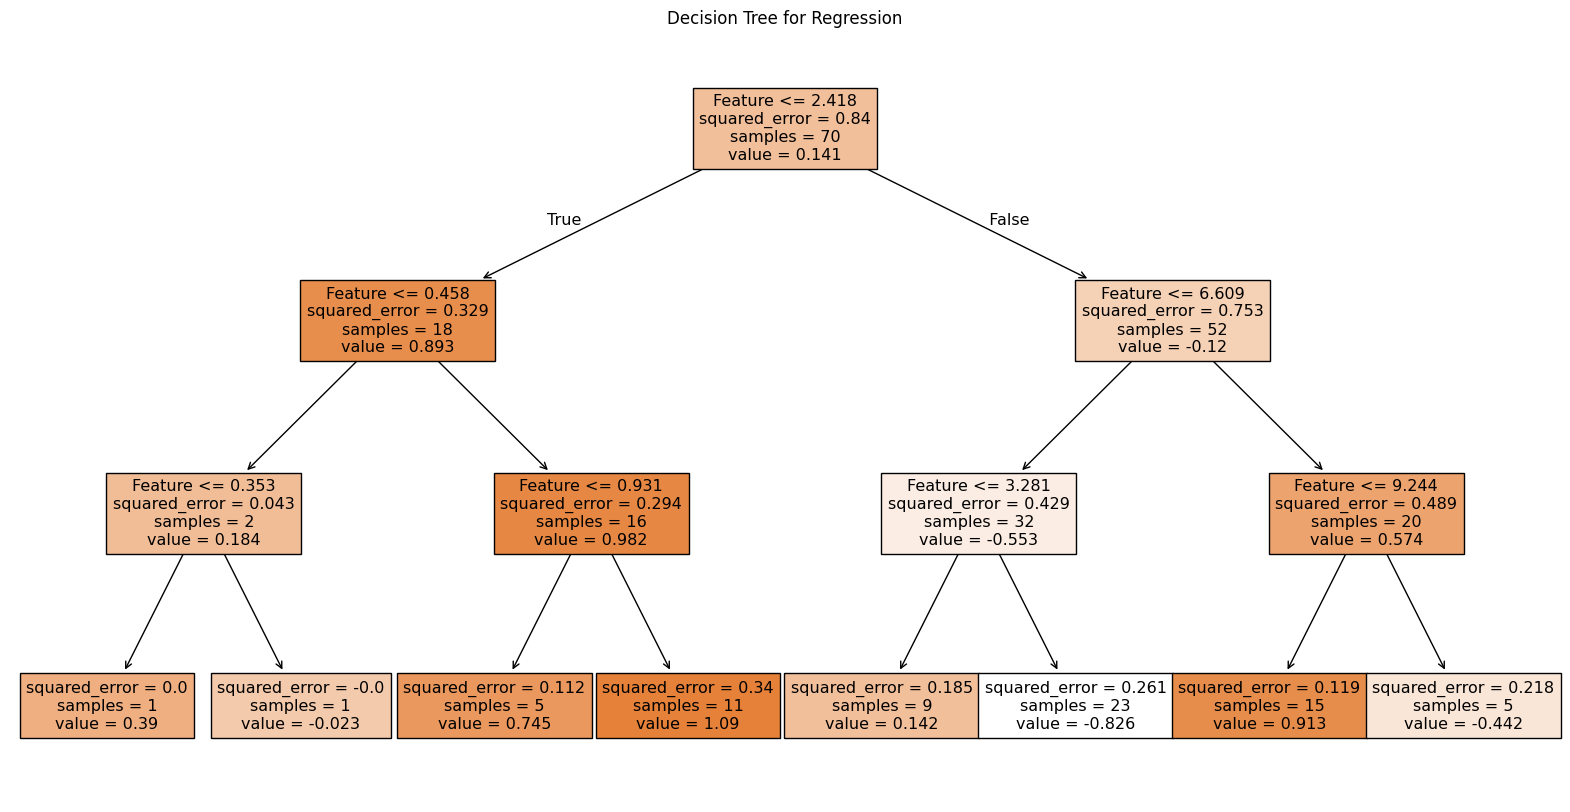

In [14]:
plt.figure(figsize=(20,10))
plot_tree(reg, feature_names=['Feature'], filled=True)
plt.title('Decision Tree for Regression')
plt.show()

### 2.8 Visualizing the Regression Results

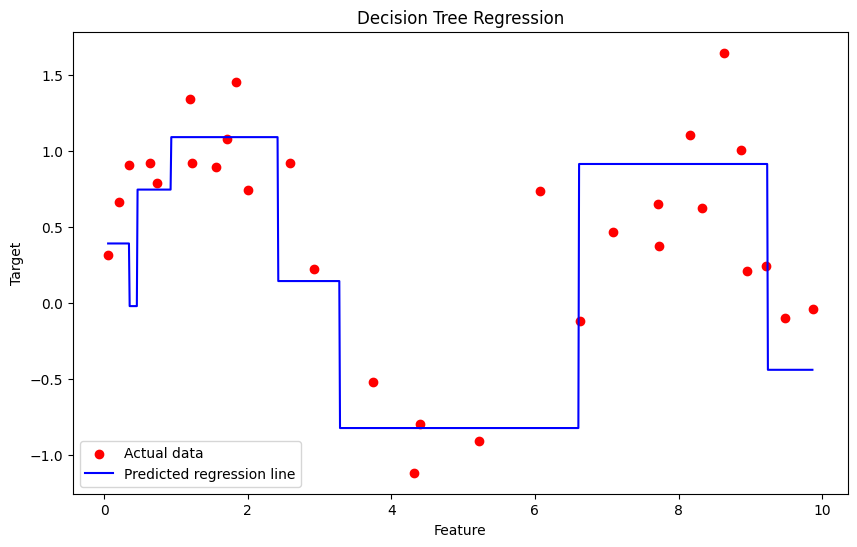

In [15]:
X_grid = np.arange(X_reg.min(), X_reg.max(), 0.01)[:, np.newaxis]
y_grid_pred = reg.predict(X_grid)

plt.figure(figsize=(10,6))
plt.scatter(X_reg_test, y_reg_test, color='red', label='Actual data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Predicted regression line')
plt.title('Decision Tree Regression')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.show()

### 2.9 Interpretation

For regression, the decision tree works similarly but predicts a continuous value instead of a class.
- Each node still represents a decision based on a feature.
- The `squared_error` (or MSE) value measures the variance of the samples in the node; a lower value is better.
- The `samples` value shows how many training samples are in the node.
- The `value` is the predicted continuous value (the average of the target values of the samples in that node).
- The visualization of the regression results shows how the tree creates a piecewise constant prediction.

## Conclusion

In this notebook, we have explored the use of decision trees for both classification and regression tasks. 

**Key Takeaways:**
- **Versatility:** Decision trees can be used for both categorical and numerical data.
- **Interpretability:** They are easy to visualize and understand, making them a 'white-box' model.
- **Prone to Overfitting:** Without constraints (like `max_depth`), decision trees can easily overfit the training data. Techniques like pruning or setting a maximum depth can help mitigate this.

Decision trees form the basis for more powerful ensemble methods like Random Forests and Gradient Boosting.